# Predicting Spotify Song Popularity from Audio Features

Can a song's audio characteristics predict how popular it becomes? This project
trains and compares three tree-based regression models on ~114k Spotify tracks
to answer that, and to identify which features carry the most signal.

**Author:** Robin Dogan ([@RobinDogan](https://github.com/RobinDogan))


## Project overview

The notebook follows an end-to-end data science workflow (excluding deployment):

1. **Define the goal** — frame the research question.
2. **Collect & manage data** — load the dataset, run quality checks, and explore feature distributions and relationships.
3. **Build models** — train three tree-based regressors.
4. **Evaluate** — compare the models using suitable regression metrics.
5. **Present results** — answer the research question and reflect on the limitations.


## 1. Define the goal

Spotify exposes detailed audio features for millions of tracks, which makes it
possible to study how musical characteristics relate to popularity. What remains
unclear is *how much* of a song's popularity these features can actually explain.

The goal of this project is therefore to test whether audio features can predict
song popularity, and to identify which features are the most informative.

**Research question:** *To what extent can audio features predict a song's
popularity on Spotify, and which features are most informative?*


## 2. Collect and manage data

The analysis uses the
[Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)
from Kaggle. It combines acoustic features (sound-related properties such as
danceability, energy, and loudness) with contextual metadata (genre, artist,
duration), which together allow an exploration of how these relate to popularity.


### Setup and data loading


In [ ]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor

# Reproducibility and display settings
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Load the dataset
df = pd.read_csv("dataset.csv", index_col=0)


### Data quality check and cleaning
Before conducting exploratory analysis, the dataset was examined for missing values, duplicate records, and potential inconsistencies to ensure that the results are reliable.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

In [ ]:
df.shape

(114000, 20)

Since the audio features are automatically generated by Spotify, the numerical variables are generally consistent and comparable across tracks.


In [ ]:
# Data quality check
n0 = len(df)

missing_per_col = df.isna().sum()
missing_total = int(missing_per_col.sum())
missing_cols = missing_per_col[missing_per_col > 0].sort_values(ascending=False)

dup_rows = int(df.duplicated().sum())

print(f"Rows: {n0}")
print(f"Total missing values: {missing_total} (columns with missing: {len(missing_cols)})")
if len(missing_cols) > 0:
    print("Missing by column:", missing_cols.to_dict())
print(f"Duplicate rows: {dup_rows}")

# Cleaning 
df = df.drop_duplicates()
after_dups = len(df)

# Drop rows with missing values 
df = df.dropna()
n_final = len(df)

print("\nAfter cleaning:")
print(f"Rows after removing duplicates: {after_dups} (removed {n0 - after_dups})")
print(f"Rows after dropping missing: {n_final} (removed {after_dups - n_final})")
print(f"Total rows removed: {n0 - n_final}")


Rows: 114000
Total missing values: 3 (columns with missing: 3)
Missing by column: {'artists': 1, 'album_name': 1, 'track_name': 1}
Duplicate rows: 450

After cleaning:
Rows after removing duplicates: 113550 (removed 450)
Rows after dropping missing: 113549 (removed 1)
Total rows removed: 451


Duplicate observations (450 rows) and a very small number of missing values (3 in total, limited to textual categorical columns) were removed.

Identifier and free-text columns (`track_id`, `track_name`, `album_name`) are
dropped, as they carry no meaningful predictive signal.


In [ ]:
df_model = df.drop(columns=["track_id", "track_name", "album_name"])


## 3. Exploratory data analysis

With a clean dataset in place, the exploratory analysis below looks for patterns,
distributions, and relationships between the audio features and popularity. These
insights guide the preprocessing and modeling choices that follow.


### Distributions


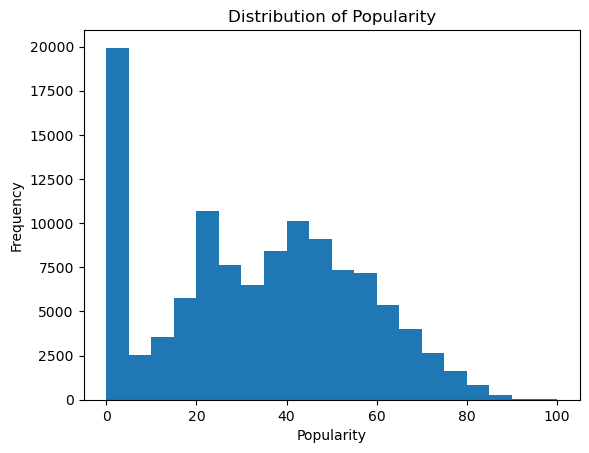

In [ ]:
# Histogram for popularity
plt.hist(df["popularity"], bins=20)
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.title("Distribution of Popularity")
plt.show()


A large proportion of tracks have zero popularity, and most tracks fall within the low-to-moderate popularity range.

### Relationships Between Features and Popularity
In this section, I explore how different audio features are related to song popularity. 

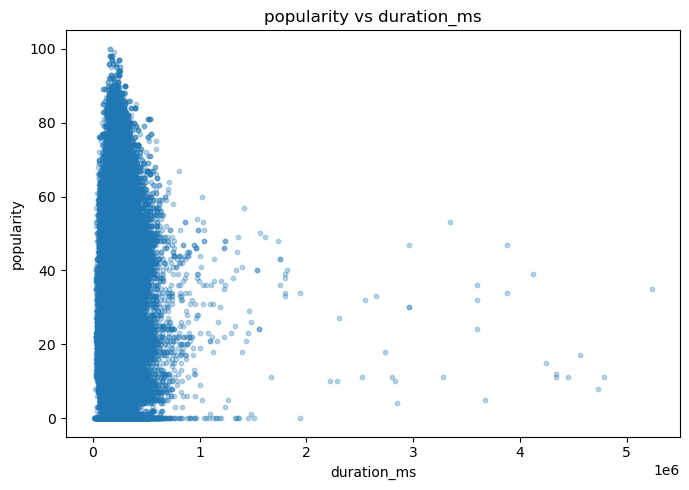

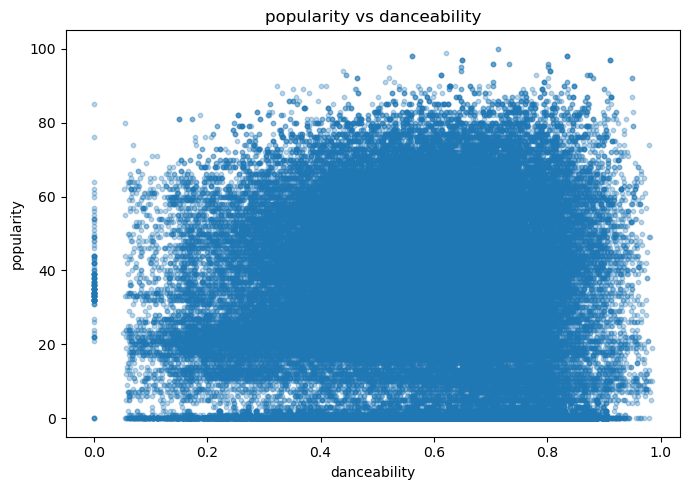

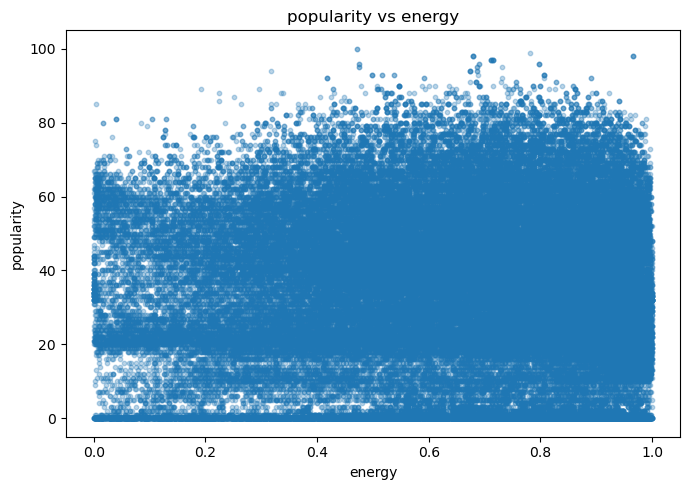

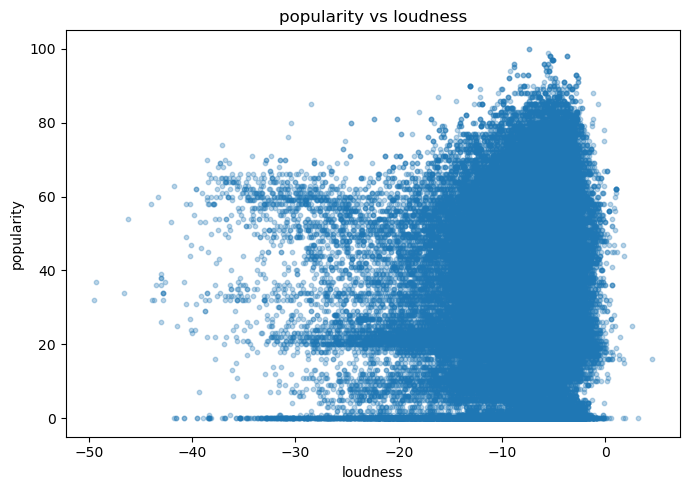

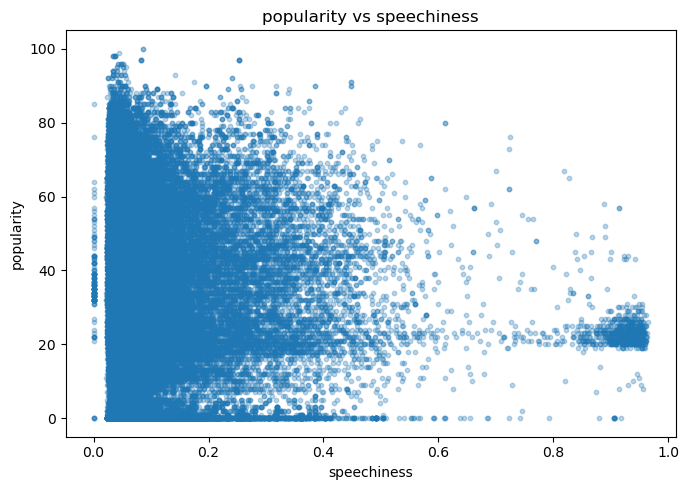

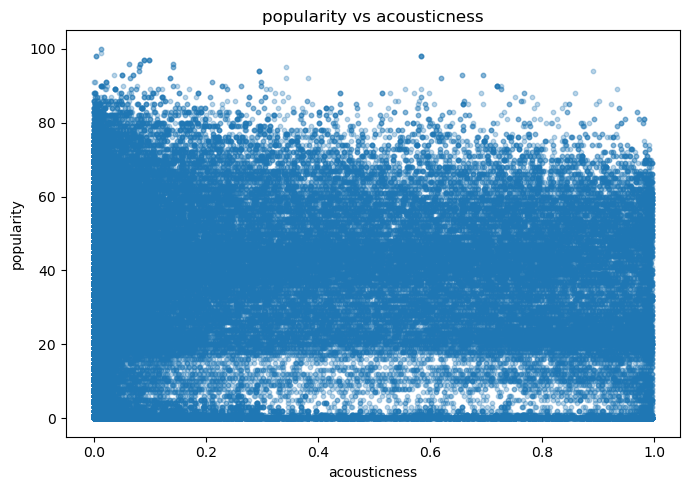

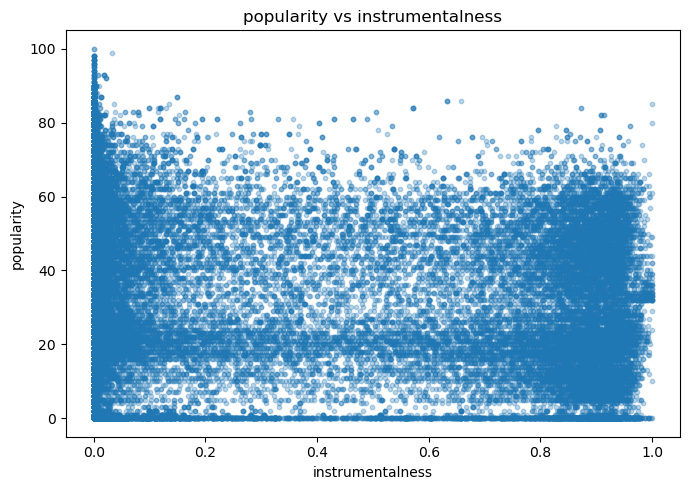

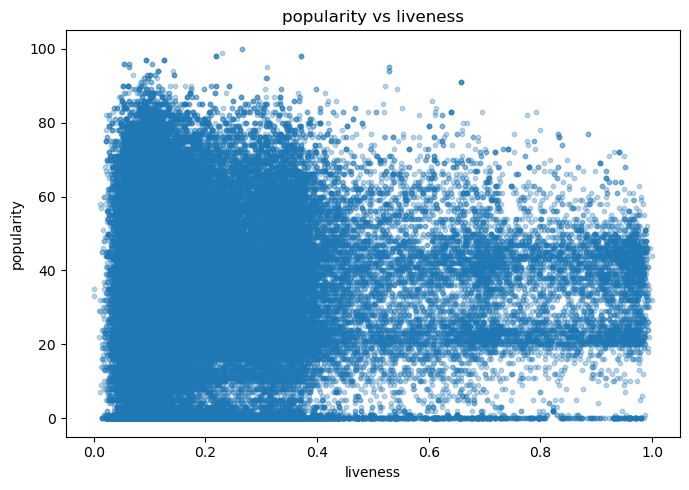

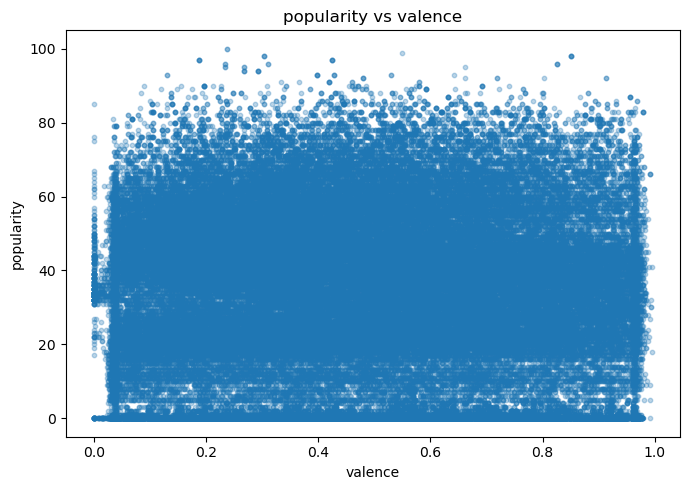

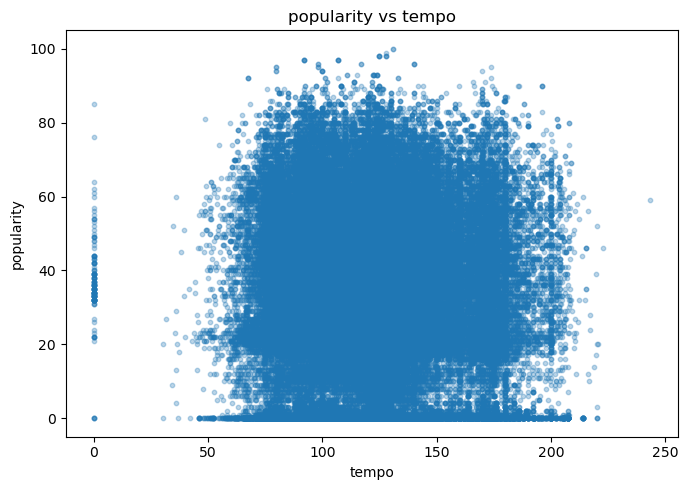

In [ ]:
target = "popularity"

# All numerical features
features = (
    df.select_dtypes(include="number")
      .columns
      .drop(target, errors="ignore")
      .tolist()
)

# Excluding categorical-like variables
exclude = {
    "key",
    "mode",
    "time_signature",
    "explicit"
}

features = [f for f in features if f not in exclude]

base = df[[target] + features].copy()

# Generating scatter plot
for f in features:

    if base[f].nunique(dropna=True) < 5:
        continue

    tmp = base[[f, target]]

    plt.figure(figsize=(7, 5))

    plt.scatter(
        tmp[f],
        tmp[target],
        alpha=0.3,   
        s=10        
    )

    plt.title(f"{target} vs {f}")
    plt.xlabel(f)
    plt.ylabel(target)

    plt.tight_layout()
    plt.show()
    plt.close()


The scatter plots show highly spread out patterns, with no clear linear or non-linear relationships between most audio features and popularity. 

<Figure size 1000x500 with 0 Axes>

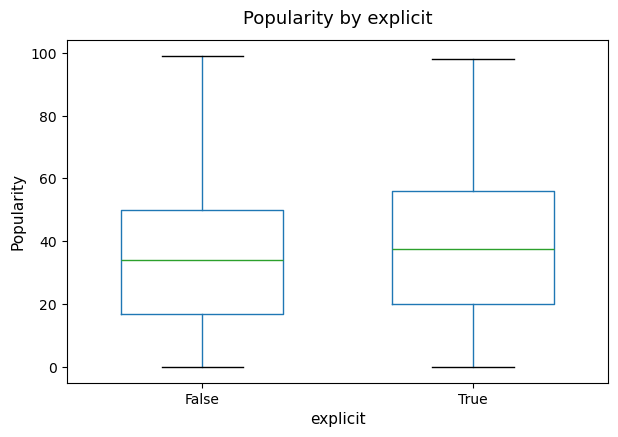

<Figure size 1000x500 with 0 Axes>

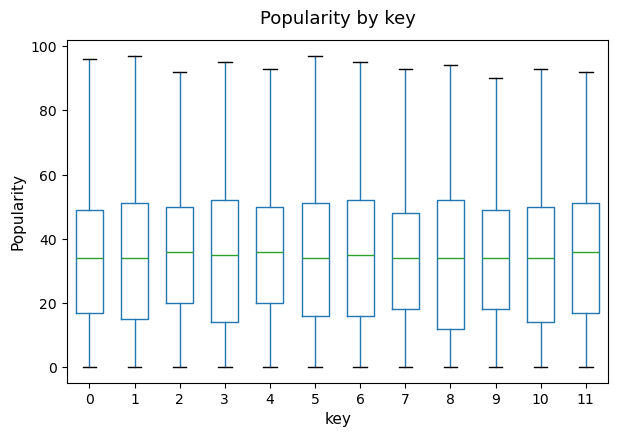

<Figure size 1000x500 with 0 Axes>

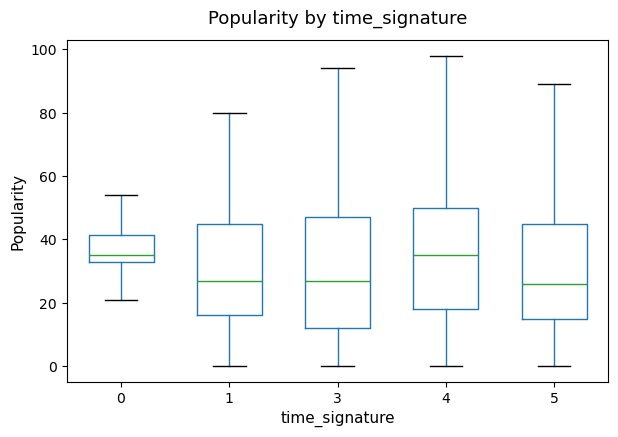

<Figure size 1000x500 with 0 Axes>

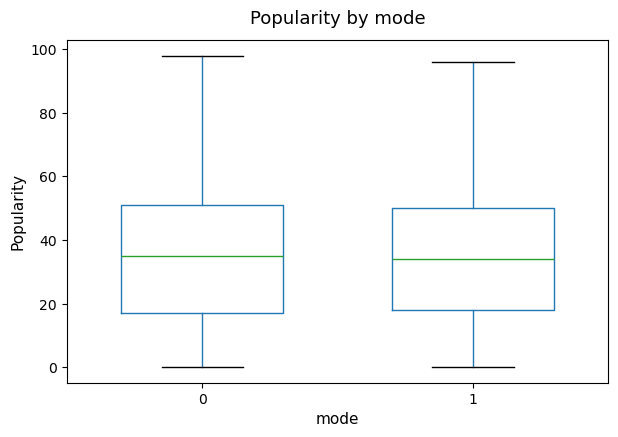

In [ ]:
target = "popularity"

# Select all categorical columns
cat_features = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Add discrete numerical variables that should be treated as categorical
extra_cats = ["key", "time_signature", "mode", "explicit"]

for c in extra_cats:
    if c in df.columns and c not in cat_features:
        cat_features.append(c)

base = df[[target] + cat_features].copy()

# Generate improved boxplots
for f in cat_features:

    if base[f].nunique() > 20:
        continue
    
    plt.figure(figsize=(10, 5))

    base.boxplot(
        column=target,
        by=f,
        grid=False,
        showfliers=False,
        widths=0.6 
    )

    plt.title(f"Popularity by {f}", fontsize=13, pad=12)
    plt.suptitle("")
    plt.xlabel(f, fontsize=11)
    plt.ylabel("Popularity", fontsize=11)

    plt.xticks(
        rotation=0,        
        ha="center",    
        fontsize=10
    )

    plt.tight_layout(pad=1.5)
    plt.show()
    plt.close()


The boxplots show strong overlap across all categories (key, mode, time signature, and explicit), with no clear differences in popularity. This indicates that these variables have limited explanatory power for predicting track popularity.

In [ ]:
# Outlier detection using IQR

numeric_cols = df.select_dtypes(include=np.number)

outlier_summary = []

for col in numeric_cols.columns:
    q1 = numeric_cols[col].quantile(0.25)
    q3 = numeric_cols[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = ((numeric_cols[col] < lower) | (numeric_cols[col] > upper)).sum()
    outlier_pct = (outliers / len(df)) * 100

    outlier_summary.append({
        "feature": col,
        "outliers": outliers,
        "outliers_%": round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("outliers", ascending=False)
outlier_df


,feature,outliers,outliers_%
9,instrumentalness,25131,22.13
7,speechiness,13167,11.60
13,time_signature,12063,10.62
10,liveness,8610,7.58
5,loudness,6115,5.39
1,duration_ms,5592,4.92
12,tempo,615,0.54
2,danceability,615,0.54
0,popularity,2,0.00
3,energy,0,0.00


There are relatively high outlier proportions for features such as instrumentalness and speechiness. These values likely reflect specific types of tracks, such as instrumental or spoken-word content, rather than noise in the data. Therefore, the outliers are kept to preserve the representativeness of the dataset. 

### Correlation Analysis
The correlation matrix helps assess the strength of linear relationships between audio features and popularity, as well as detect multicollinearity among the features themselves.

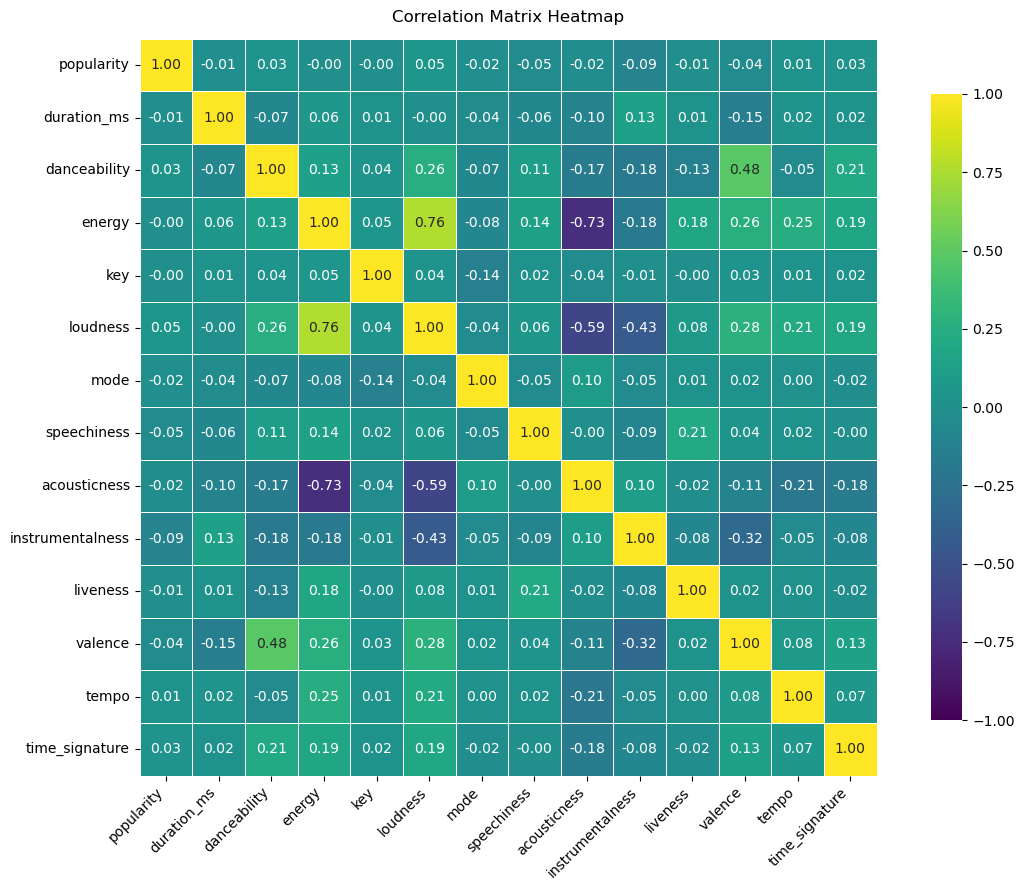

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.85},
    vmin=-1, vmax=1
)

plt.title("Correlation Matrix Heatmap", pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Summary of correlation analysis:
The correlation matrix shows that popularity has only weak linear relationships with all individual audio features. In addition, most features are not strongly correlated with each other.

This suggests that popularity is difficult to explain using single features alone and is likely influenced by more complex interactions between multiple variables. These observations motivate the use of non-linear models that can capture such relationships.

## 4. Preprocessing
I encoded the categorical variables using ordinal encoding, which is suitable for tree-based models and allows categorical information to be included without strong assumptions. To avoid data leakage, the encoder is fitted only on the training set and then applied to the test set.

Finally, the dataset is split into training and test sets.

In [ ]:
# Target and features
X = df_model.drop(columns=["popularity"])
y = df_model["popularity"]

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

# Categorical columns
categorical_cols = X_train.select_dtypes(include="object").columns
print("Categorical columns:", list(categorical_cols))

# Ordinal encoding
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols].astype(str))
X_test[categorical_cols]  = encoder.transform(X_test[categorical_cols].astype(str))


Train size: (90839, 16), Test size: (22710, 16)
Categorical columns: ['artists', 'track_genre']


## 5. Building the models
Based on the EDA results, which indicated weak linear relationships, I used tree-based methods that can capture non-linear patterns and interactions between audio features. These models are well-suited for handling complex feature relationships without strong distributional assumptions. 

I choose ensemble methods with different strategies: **Random Forest**, which uses the bagging technique (multiple decision trees are trained on different bootstrap samples of the data); **Gradient Boosting**, which uses a boosting approach (trees are built sequentially, each correcting the errors of the previous ones); and **XGBoost**, which is a more advanced boosting algorithm. 

### Random Forest 

In [ ]:
rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1, random_state=42)

### Gradient Boosting

In [ ]:
gbr = GradientBoostingRegressor(
    random_state=RANDOM_STATE,
    max_depth=6
)

gbr.fit(X_train, y_train)


GradientBoostingRegressor(max_depth=6, random_state=42)

### XGBoost

In [ ]:
xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=-1, num_parallel_tree=None, ...)

## 6. Evaluate the models

Model performance is assessed with two metrics: **MAE**, the average absolute
difference between predicted and actual popularity, and **R²**, the proportion of
variance in popularity explained by the model. R² is also used to compare overall
model fit across the three regressors.


In [ ]:
models = {
    "Random Forest": rf,
    "Gradient Boosting": gbr,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    if hasattr(model, "feature_names_in_"):
        X_eval = X_test.reindex(columns=model.feature_names_in_, fill_value=0)
    else:
        X_eval = X_test.select_dtypes(include="number")

    preds = model.predict(X_eval)

    results.append({
        "Model": name,
        "R2": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds)
    })

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
results_df


,Model,R2,MAE
0,Random Forest,0.516034,10.885263
2,XGBoost,0.411518,12.768706
1,Gradient Boosting,0.328350,14.128050


# Present the results
Among the evaluated models, Random Forest achieved the highest R² and the lowest MAE, indicating the strongest overall performance in this comparison. This suggests that deeper trees may be more suitable for this dataset, where complex interactions between features are likely present. However, the differences between the models remain moderate.

An R² value of approximately 0.52 suggests that around half of the variation in song popularity can be explained by audio features alone. While this shows that musical characteristics play an important role, a substantial part of popularity remains influenced by external factors not captured in the dataset. 

Overall, these results suggest that while machine learning models can identify meaningful patterns in audio data to some extent, song popularity is influenced by a combination of musical, social, and platform-related factors. As a result, the models do not achieve substantially higher performance.


## Feature Importance in Tree-based Models


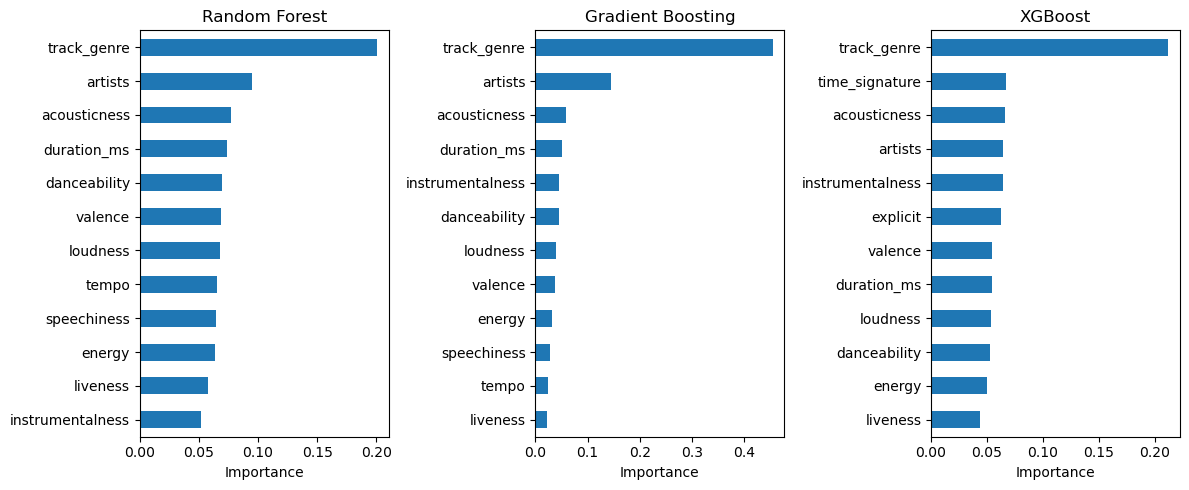

In [ ]:
models_to_plot = {
    "Random Forest": models["Random Forest"],
    "Gradient Boosting": models["Gradient Boosting"],
    "XGBoost": models["XGBoost"]
}

# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, (name, model) in zip(axes, models_to_plot.items()):

    # Get feature names
    if hasattr(model, "feature_names_in_"):
        feature_names = model.feature_names_in_
    else:
        feature_names = X_train.columns

    # Build importance Series
    importances = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=True)

    # Select top 12 and plot
    top12 = importances.tail(12)
    top12.plot(kind="barh", ax=ax)

    ax.set_title(name)
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()


### Feature Importance Summary

- Across all three models, track_genre consistently appears as one of the most important features. This suggests that differences in popularity are strongly related to musical genre, likely reflecting variations in audience size and listening behavior across genres.

- At the same time, this does not mean that genre alone determines popularity. Rather, it provides a broad contextual signal that the models rely on when making predictions.

- In contrast, individual acoustic features such as danceability, energy, valence, and loudness tend to have more moderate importance.

## 7. Reflection and future work

This project showed that audio features alone provide limited predictive power
for song popularity. Although the tree-based ensembles captured non-linear
relationships, a substantial part of the variation in popularity remained
unexplained.

This highlights an important limitation of the dataset: many external factors
that strongly influence popularity — marketing, playlist placement, social-media
exposure, and artist reputation — are not represented, which limits how well the
models can perform.

Future work could apply systematic hyperparameter optimization and
cross-validation to push performance further, and incorporate external contextual
data to build more realistic and informative prediction models.
